# Predict Immune Hotspots

### Goal: 
Predict immune-high spatial spots from gene expression and identify genes that drive the prediction.

## 1. Load Data

In [15]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

In [16]:
adata = sc.read_h5ad("../data/processed/breast_cancer_spatial_analysis.h5ad")
adata

AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'leiden_0_5', 'leiden_0_2', 'leiden_0_4', 'leiden_0_6', 'leiden_0_8', 'leiden_1_0'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden_0_2', 'leiden_0_2_colors', 'leiden_0_4', 'leiden_0_4_colors', 'leiden_0_5', 'leiden_0_5_centrality_scores', 'leiden_0_5_co_occurrence', 'leiden_0_5_colors', 'leiden_0_5_nhood_enrichment', 'leiden_0_6', 'leiden_0_6_colors', 'leiden_0_8', 'leiden_0_8_colors', 'leiden_1_0', 'leiden_1_0_colors', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial

## 2. Recreate Immune Score

In [17]:
immune_genes = ["PTPRC", "CD3D", "CD74", "HLA-DRA", "HLA-DPB1"]
immune_genes = [g for g in immune_genes if g in adata.var_names]

sc.tl.score_genes(
    adata,
    gene_list=immune_genes,
    score_name="immune_score"
)

## 3. Create Target Label

1 = immune-high spot
0 = not immune-high spot

In [18]:
adata.obs["immune_binary"] = (
    adata.obs["immune_score"] > 1
).astype(int)

adata.obs["immune_binary"].value_counts()

immune_binary
0    3383
1     415
Name: count, dtype: int64

## 4. Build Feature Matrix

In [19]:
if "highly_variable" in adata.var.columns:
    adata_ml = adata[:, adata.var["highly_variable"]].copy()
else:
    adata_ml = adata.copy()

In [20]:
X = adata_ml.X

if not isinstance(X, np.ndarray):
    X = X.toarray()

y = adata.obs["immune_binary"].values

X.shape, y.shape

((3798, 3000), (3798,))

## 5. Train/Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

## 6. Model 1 - Logistic Regression

In [22]:
logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced"
    ))
])

logreg_model.fit(X_train, y_train)

y_pred = logreg_model.predict(X_test)
y_prob = logreg_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       846
           1       0.58      0.51      0.54       104

    accuracy                           0.91       950
   macro avg       0.76      0.73      0.75       950
weighted avg       0.90      0.91      0.90       950

ROC AUC: 0.9029368976177486


## 7. ROC Curve

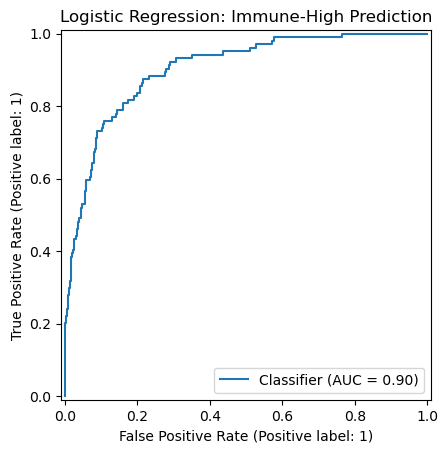

In [23]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Logistic Regression: Immune-High Prediction")
plt.show()

## 8. Model 2 - Random Forest

In [24]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95       846
           1       0.61      0.74      0.67       104

    accuracy                           0.92       950
   macro avg       0.79      0.84      0.81       950
weighted avg       0.93      0.92      0.92       950

ROC AUC: 0.9519458083287872


## 9. Feature Importance

In [25]:
feature_names = adata_ml.var_names

importances = pd.DataFrame({
    "gene": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importances.head(20)

,gene,importance
259,PTPRC,0.026305
970,HLA-DPB1,0.025116
37,C1QA,0.021003
2555,C3,0.020472
1899,LYZ,0.019886
1225,TRBC2,0.016008
964,HLA-DQA1,0.015524
969,HLA-DPA1,0.015368
965,HLA-DQB1,0.013733
39,C1QB,0.013306


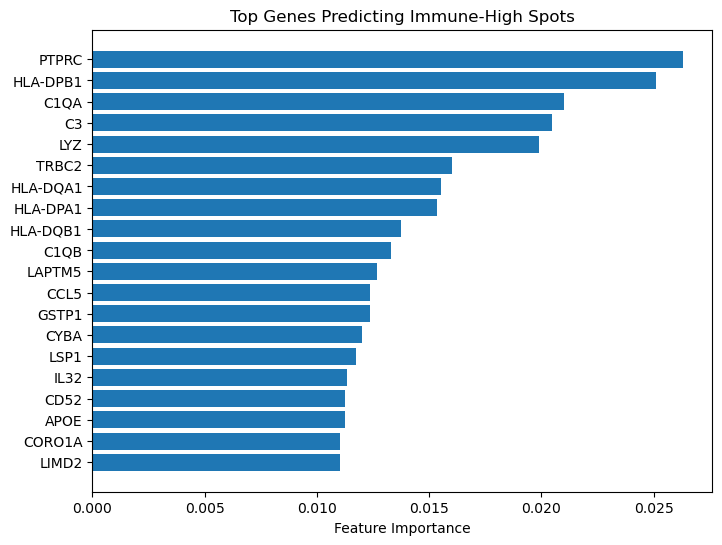

In [26]:
# Plot

top = importances.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top["gene"][::-1], top["importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Top Genes Predicting Immune-High Spots")
plt.show()

## 10. Save Results

In [27]:
importances.to_csv(
    "../reports/figures/immune_hotspot_feature_importance.csv",
    index=False
)

## Interphretation

Random forest feature importance identified immune-associated genes as the strongest predictors of immune-rich spatial niches. Top features included PTPRC, TRBC2, HLA-DPB1, HLA-DQA1, HLA-DQB1, C1QA, C1QB, and CCL5, indicating that antigen presentation, T-cell activity, and macrophage-associated programs are major contributors to localized immune enrichment within the tissue.